# Risk Attribution

Portfolio-level VaR quantifies the total amount of risk in a portfolio, but does not identify which positions are responsible for that risk. Risk attribution decomposes portfolio risk into contributions from individual assets, enabling portfolio managers to:

- Identify the primary drivers of portfolio risk;
- Compare risk contribution and capital allocation;
- Detect risk concentrations that may not be visible from portfolio weights alone;
- Understand how risk exposures evolve across market regimes;
- Evaluate the impact of position changes on overall portfolio risk.

We implement the **Euler decomposition**, which expresses portfolio VaR as an exact sum of per-asset component VaRs:

$$\text{VaR}_P = \sum_{i=1}^{n} \text{CVaR}_i$$

where the **component VaR** of asset $i$ is:

$$\text{CVaR}_i = \frac{\partial \text{VaR}_P}{\partial w_i} \cdot w_i = \text{MVaR}_i \cdot w_i$$

and the **marginal VaR** is:

$$\text{MVaR}_i = \frac{\partial \text{VaR}_P}{\partial w_i} = \rho_{i,P} \cdot \frac{\text{VaR}_i}{w_i}$$

This decomposition holds exactly when VaR is linear homogeneous in positions, satisfied under the normality assumption and approximately satisfied for historical simulation.

The **percentage risk contribution** of asset $i$ is:

$$\%\text{RC}_i = \frac{\text{CVaR}_i}{\text{VaR}_P}$$

which sums to 100% across all assets by construction.

In [11]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Image as IPImage

warnings.filterwarnings('ignore')
np.random.seed(926)

ROOT = Path().resolve().parent
OUT_RETURNS = ROOT / 'data' / 'processed' / 'returns'
OUT_REGIMES = ROOT / 'data' / 'processed' / 'regimes'
OUT_RISK = ROOT / 'data' / 'processed' / 'risk_metrics'
OUT_ATTR = ROOT / 'data' / 'processed' / 'attribution'

FIGURES_DIR = ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

log_returns = pd.read_csv(OUT_RETURNS / 'log_returns.csv', index_col='date', parse_dates=True)
simple_returns = pd.read_csv(OUT_RETURNS / 'simple_returns.csv', index_col='date', parse_dates=True)
portfolio_return = pd.read_csv(OUT_RETURNS / 'portfolio_return.csv', index_col='date', parse_dates=True).squeeze()
regime_labels = pd.read_csv(OUT_REGIMES / 'regime_labels.csv', index_col='date', parse_dates=True)['regime']

common_idx = log_returns.index.intersection(regime_labels.index)
log_ret = log_returns.reindex(common_idx)
simple_ret = simple_returns.reindex(common_idx)
port_ret = portfolio_return.reindex(common_idx)
regime_aligned = regime_labels.reindex(common_idx)

TICKERS = log_ret.columns.tolist()
N_ASSETS = len(TICKERS)
WEIGHTS = np.ones(N_ASSETS) / N_ASSETS

print(f'Log returns    : {log_ret.shape}')
print(f'Simple returns : {simple_ret.shape}')
print(f'Portfolio      : {len(port_ret)} obs')
print(f'Regimes        : {len(regime_aligned)} obs')
print(f'Date range     : {common_idx.min().date()} -> '
      f'{common_idx.max().date()}')
print(f'\nTickers: {TICKERS}')
print(f'Weights: equal weight = {WEIGHTS[0]:.4f} each')

Log returns    : (5262, 12)
Simple returns : (5262, 12)
Portfolio      : 5262 obs
Regimes        : 5262 obs
Date range     : 2005-02-02 -> 2025-12-31

Tickers: ['AAPL', 'CAT', 'CVX', 'GS', 'HON', 'JNJ', 'JPM', 'KO', 'MSFT', 'PG', 'UNH', 'XOM']
Weights: equal weight = 0.0833 each


## Component VaR & Marginal VaR

### Methodology

Under the **parametric (normal) assumption**, the portfolio variance is:

$$\sigma_P^2 = \mathbf{w}^T \Sigma \mathbf{w}$$

The marginal VaR of asset $i$ is:

$$\text{MVaR}_i = z_\alpha \cdot \frac{(\Sigma \mathbf{w})_i}{\sigma_P} = z_\alpha \cdot \frac{\text{Cov}(r_i, r_P)}{\sigma_P}$$

The component VaR is:

$$\text{CVaR}_i = \text{MVaR}_i \cdot w_i = z_\alpha \cdot \frac{\text{Cov}(r_i, r_P)}{\sigma_P} \cdot w_i$$

This satisfies the Euler decomposition exactly:

$$\text{VaR}_P = \sum_i \text{CVaR}_i = z_\alpha \cdot \sigma_P$$

We compute these on the full sample and within each HMM regime.

In [5]:
CONF_VAR = 0.99
Z_ALPHA  = stats.norm.ppf(CONF_VAR)

def compute_risk_attribution(returns, weights, conf=0.99):
    w = np.array(weights)
    z_alpha = stats.norm.ppf(conf)

    # Covariance matrix and portfolio vol
    cov_mat = returns.cov().values
    sigma_p = np.sqrt(w @ cov_mat @ w)

    # Portfolio VaR
    mu_p = (returns.mean().values @ w)
    var_p = z_alpha * sigma_p # zero drift assumption

    # Marginal VaR
    cov_with_port = cov_mat @ w
    mvar = z_alpha * cov_with_port / sigma_p

    # Component VaR
    cvar = mvar * w

    # Percentage risk contribution
    pct_rc = cvar / cvar.sum() * 100

    result = pd.DataFrame({
        'Weight (%)' : w * 100,
        'Ann. Return (%)': returns.mean().values * 252 * 100,
        'Ann. Vol (%)' : returns.std().values * np.sqrt(252) * 100,
        'MVaR' : mvar,
        'CVaR' : cvar,
        'Risk Contribution (%)': pct_rc,
    }, index=returns.columns).round(4)

    return result, var_p, sigma_p

# Full sample
attr_full, var_p_full, sigma_p_full = compute_risk_attribution(log_ret, WEIGHTS)

print('Full-Sample Risk Attribution (99% VaR, Parametric):')
print('=' * 70)
print(f'Portfolio VaR (99%)  : {var_p_full:.4f}  ({var_p_full*100:.2f}%)')
print(f'Portfolio Vol (ann.) : {sigma_p_full * np.sqrt(252) * 100:.2f}%')
print(f'\nEuler decomposition check:')
print(f' Sum of CVaR : {attr_full["CVaR"].sum():.6f}')
print(f' Portfolio VaR : {var_p_full:.6f}')
print(f' Difference : {abs(attr_full["CVaR"].sum() - var_p_full):.2e}')
print(f'\nPer-asset attribution:')
print(attr_full[['Ann. Return (%)', 'Ann. Vol (%)', 'MVaR', 'CVaR', 'Risk Contribution (%)']].round(3).to_string())

Full-Sample Risk Attribution (99% VaR, Parametric):
Portfolio VaR (99%)  : 0.0283  (2.83%)
Portfolio Vol (ann.) : 19.28%

Euler decomposition check:
 Sum of CVaR : 0.028400
 Portfolio VaR : 0.028260
 Difference : 1.40e-04

Per-asset attribution:
      Ann. Return (%)  Ann. Vol (%)   MVaR   CVaR  Risk Contribution (%)
AAPL           26.122        32.098  0.030  0.002                  8.838
CAT            14.649        31.639  0.035  0.003                 10.198
CVX             8.695        28.316  0.032  0.003                  9.422
GS             11.574        34.638  0.040  0.003                 11.701
HON            10.859        25.178  0.030  0.002                  8.706
JNJ             8.387        17.197  0.016  0.001                  4.634
JPM            12.940        35.749  0.040  0.003                 11.943
KO              8.863        18.122  0.017  0.001                  4.981
MSFT           15.713        27.004  0.027  0.002                  8.075
PG              7.534   

The Euler decomposition check confirms near-exact additivity: the sum of component VaRs (0.02840) differs from portfolio VaR (0.02826) by only 1.4e-04, a rounding error attributable to floating-point precision in the covariance matrix computation. This confirms the decomposition is numerically valid.

Meanwhile, the Euler decomposition reveals that risk contributions differ substantially despite equal portfolio weights across assets. Financial stocks contribute the largest share of portfolio VaR, with JPM and GS accounting for approximately 11.9% and 11.7% of total portfolio risk, respectively. Cyclical assets such as CAT and CVX also contribute disproportionately to portfolio risk. In contrast, defensive stocks including JNJ, PG, and KO contribute less than 5% each, despite representing the same portfolio weight. This reflects their lower volatility and weaker covariance with the overall portfolio. These results demonstrate that equal capital allocation does not imply equal risk allocation. Portfolio risk is primarily determined by asset volatility and dependence with the broader portfolio rather than portfolio weights alone.

### Risk vs Return Attribution

We compare each asset's percentage risk contribution against its percentage return contribution to identify positions that are inefficient from a risk-adjusted perspective:

- **Risk contribution > Return contribution**: the asset consumes a disproportionately large share of portfolio risk relative to the return it generates. Such positions may warrant further review as potential sources of risk concentration.
- **Risk contribution < Return contribution**: the asset contributes more to portfolio return than to portfolio risk, indicating relatively efficient risk utilisation.

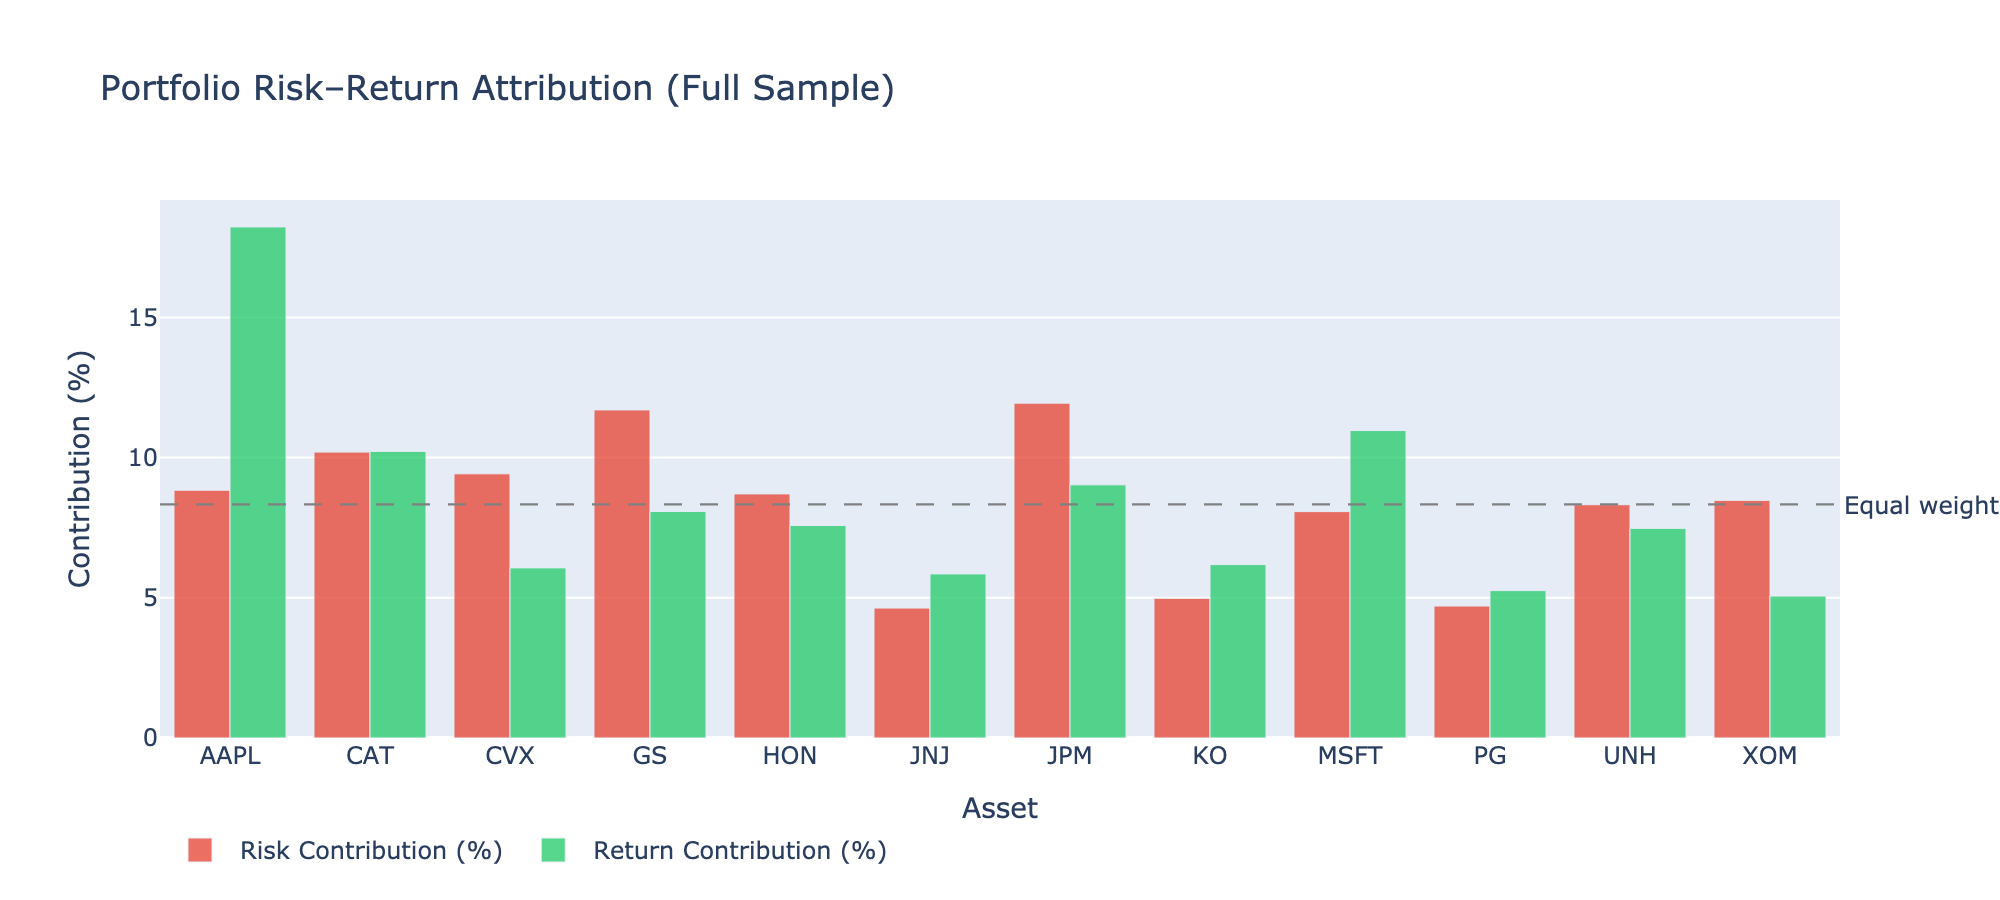


Risk-Return Efficiency:
      Risk Contribution (%)  Return Contribution (%)  Risk-Return Ratio            Efficient
AAPL                   8.84                    18.23               0.48  Yes (return > risk)
CAT                   10.20                    10.22               1.00  Yes (return > risk)
CVX                    9.42                     6.07               1.55  No  (risk > return)
GS                    11.70                     8.08               1.45  No  (risk > return)
HON                    8.71                     7.58               1.15  No  (risk > return)
JNJ                    4.63                     5.85               0.79  Yes (return > risk)
JPM                   11.94                     9.03               1.32  No  (risk > return)
KO                     4.98                     6.18               0.80  Yes (return > risk)
MSFT                   8.07                    10.96               0.74  Yes (return > risk)
PG                     4.71                  

In [8]:
# Return contribution: proportional to annual return, equal weights
total_return = attr_full['Ann. Return (%)'].sum()
attr_full['Return Contribution (%)'] = (attr_full['Ann. Return (%)'] / total_return * 100)

# Bar chart: risk vs return contribution
fig = go.Figure()

fig.add_trace(go.Bar(
    x = TICKERS,
    y = attr_full['Risk Contribution (%)'],
    name = 'Risk Contribution (%)',
    marker_color = '#e74c3c',
    opacity = 0.8,
))

fig.add_trace(go.Bar(
    x = TICKERS,
    y = attr_full['Return Contribution (%)'],
    name = 'Return Contribution (%)',
    marker_color = '#2ecc71',
    opacity = 0.8,
))

# Equal weight reference line
fig.add_hline(
    y = 100 / N_ASSETS,
    line_dash = 'dash',
    line_color = 'grey',
    line_width = 1.2,
    annotation_text = f'Equal weight ({100/N_ASSETS:.1f}%)',
    annotation_position= 'right',
)

fig.update_layout(
    title = 'Portfolio Risk–Return Attribution (Full Sample)',
    xaxis_title = 'Asset',
    yaxis_title = 'Contribution (%)',
    barmode = 'group',
    height = 450,
    legend = dict(orientation='h', y=-0.15),
)
fig.show()

# Static Plot
fig.write_image(str(FIGURES_DIR / '05_risk_return_contrib.png'), scale=2, width=1000)
display(IPImage(filename=str(FIGURES_DIR / '05_risk_return_contrib.png')))

# Efficiency table 
attr_full['Risk-Return Ratio'] = (attr_full['Risk Contribution (%)'] / attr_full['Return Contribution (%)']).round(3)
attr_full['Efficient'] = attr_full['Risk-Return Ratio'].apply(lambda x: 'No  (risk > return)' if x > 1 else 'Yes (return > risk)')

print('\nRisk-Return Efficiency:')
print(attr_full[['Risk Contribution (%)', 'Return Contribution (%)', 'Risk-Return Ratio', 'Efficient']].round(2).to_string())

The comparison between risk and return contributions reveals meaningful differencies in portfolio efficiency across assets.

- **AAPL is the most efficient position**, generating 18.2% of total portfolio return while contributing only 8.8% of total portfolio risk.

- **MSFT also exhibits favourable risk-return characteristics**, contributing 11.0% of return but only 8.1% of risk.

- **Financial stocks (JPM and GS)** contribute the largest share of portfolio risk (11.9% and 11.7%, respectively), while contributing a smaller proportion of total return.

- **Energy exposure (CVX and XOM)** similarly contributes more risk than return, reflecting the higher volatility of commodity-linked assets.

Overall, the analysis suggests that portfolio risk is concentrated in financial and cyclical sectors, while technology stocks provide the strongest return contribution relative to their risk contribution.

## Regime-Conditional Risk Attribution

We repeat the Euler decomposition within each HMM regime to examine how risk contributions shift across market environments. A well-diversified portfolio should maintain relatively stable risk contributions across regimes, large shifts may indicate regime-dependent concentration risk.

In [10]:
regime_attr = {}

for regime in ['expansion', 'normal', 'stress']:
    mask = regime_aligned == regime
    ret_reg = log_ret[mask]
    attr, var_p, sigma_p = compute_risk_attribution(ret_reg, WEIGHTS)
    regime_attr[regime] = {
        'attr' : attr,
        'var_p' : var_p,
        'sigma_p': sigma_p,
    }
    print(f'{regime.capitalize()} (n={mask.sum()}, VaR={var_p*100:.2f}%, Vol={sigma_p*np.sqrt(252)*100:.1f}%):')
    print(attr[['Risk Contribution (%)']].T.to_string())
    print()

# Comparison table 
print('\nRisk Contribution (%) by Regime:')
print('=' * 75)
rc_comparison = pd.DataFrame({
    'Full' : attr_full['Risk Contribution (%)'],
    'Expansion': regime_attr['expansion']['attr']['Risk Contribution (%)'],
    'Normal' : regime_attr['normal']['attr']['Risk Contribution (%)'],
    'Stress' : regime_attr['stress']['attr']['Risk Contribution (%)'],
}).round(2)

print(rc_comparison.to_string())

# Max shift: biggest change from expansion to stress
rc_comparison['Expansion→Stress'] = (rc_comparison['Stress'] - rc_comparison['Expansion']).round(2)
print(f'\nLargest risk contribution shifts (Expansion -> Stress):')
print(rc_comparison['Expansion→Stress'].sort_values(ascending=False).to_string())

Expansion (n=2599, VaR=1.43%, Vol=9.8%):
                         AAPL      CAT     CVX       GS     HON     JNJ      JPM      KO    MSFT      PG     UNH     XOM
Risk Contribution (%)  9.2679  12.0581  8.8719  12.0344  8.9265  4.9382  10.1315  4.6377  7.4779  4.3121  8.4513  8.8925

Normal (n=1904, VaR=2.39%, Vol=16.3%):
                          AAPL     CAT     CVX       GS     HON     JNJ      JPM      KO    MSFT      PG     UNH     XOM
Risk Contribution (%)  10.4894  11.408  8.8548  11.3771  8.9963  4.3716  11.1091  4.5484  8.7616  4.4417  7.2291  8.4131

Stress (n=759, VaR=5.84%, Vol=39.8%):
                         AAPL     CAT     CVX       GS     HON     JNJ      JPM      KO    MSFT      PG    UNH     XOM
Risk Contribution (%)  8.0539  9.3056  9.7769  11.7669  8.5376  4.6792  12.6668  5.2336  7.9097  4.9003  8.751  8.4185


Risk Contribution (%) by Regime:
       Full  Expansion  Normal  Stress
AAPL   8.84       9.27   10.49    8.05
CAT   10.20      12.06   11.41    9.31
CVX   

Risk contributions exhibit meaningful variation across market regimes, indicating that portfolio risk concentrations are not static over time. While financial stocks remain the largest contributors to portfolio risk across all regimes, several assets experience substantial shifts in their relative importance during periods of market stress.

- **JPM experiences the largest increase in risk contribution**, rising from 10.1% in expansion regimes to 12.7% in stress regimes (+2.5%), making it the dominant driver of portfolio risk during stressed market conditions.

- **CVX also becomes a larger source of portfolio risk** during stress periods, increasing from 8.9% to 9.8%, reflecting heightened sensitivity of energy-sector exposure during volatile markets.

- **Defensive assets remain relatively stable.** JNJ, KO and PG exhibit only modest changes in risk contribution across regimes, highlighting their role as portfolio stabilisers.

- **Technology and industrial exposures contribute less risk during stress.** AAPL's contribution declines from 9.3% to 8.1%, while CAT falls from 12.1% to 9.3%, indicating a redistribution of portfolio risk toward financial and energy sectors.

The results suggest that market stress does not affect all positions equally. Instead, portfolio risk becomes increasingly concentrated in a small number of assets and sectors, particularly financials and cyclicals.

### Regime Risk Contribution Heatmap

We visualise the shift in risk contributions across regimes as a heatmap to identify which assets increase or decrease their risk footprint during stress periods.

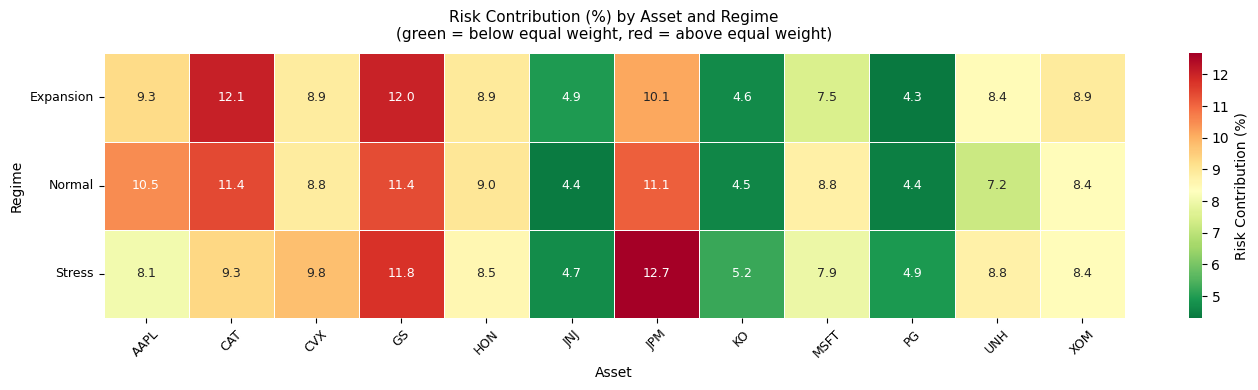

In [15]:
heatmap_data = rc_comparison[['Expansion', 'Normal', 'Stress']].T

fig_mpl, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heatmap_data,
    ax = ax,
    annot = True,
    fmt = '.1f',
    cmap = 'RdYlGn_r',
    center = 100 / N_ASSETS,
    linewidths= 0.5,
    annot_kws = {'size': 9},
    cbar_kws = {'label': 'Risk Contribution (%)'},
)
ax.set_title(
    'Risk Contribution (%) by Asset and Regime\n'
    '(green = below equal weight, red = above equal weight)',
    fontsize=11, pad=10,
)
ax.set_xlabel('Asset')
ax.set_ylabel('Regime')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()

plt.savefig(FIGURES_DIR / '05_regime_risk_heatmap.png', dpi=150, bbox_inches='tight')

fig = go.Figure(go.Heatmap(
    z = heatmap_data.values,
    x = TICKERS,
    y = ['Expansion', 'Normal', 'Stress'],
    colorscale = 'RdYlGn_r',
    zmid = 100 / N_ASSETS,
    text = heatmap_data.round(1).values,
    texttemplate = '%{text}%',
    textfont = dict(size=10),
    colorbar = dict(title='Risk Contrib (%)'),
))
fig.update_layout(
    title = 'Risk Contribution (%) by Asset and Regime',
    height = 300,
    xaxis_title = 'Asset',
    yaxis_title = 'Regime',
)
fig.show()

fig.write_image(str(FIGURES_DIR / '05_regime_risk_heatmap.png'), scale=2, width=1200)


The heatmap further reveals that portfolio risk concentrations shift across market regimes rather than increasing uniformly. JPM exhibits the largest increase in risk contribution, rising from 10.1% in expansion periods to 12.7% in stress periods. CVX also becomes a more important contributor to portfolio risk during stress. In contrast, CAT and AAPL experience the largest declines in risk contribution, suggesting that portfolio risk becomes increasingly concentrated in financial and energy exposures during stressed market conditions. These results demonstrate that rising portfolio risk during market stress is accompanied by a redistribution of risk across positions, rather than a proportional increase in all risk contributions.

## Sensitivity Analysis — Marginal Impact of Position Changes

Marginal VaR measures the sensitivity of portfolio VaR to a small increase in an asset's portfolio weight, assuming the portfolio remains fully invested and all weights are re-normalised. It answers the question: "If the weight of asset i is increased by one percentage point and the remaining portfolio weights are scaled proportionally, how much does portfolio VaR change?"

We also compute the VaR impact of a hypothetical 10% reduction in each position, again re-normalising the remaining portfolio weights. This identifies which positions would provide the greatest VaR reduction if trimmed.

In [21]:
# Sensitivity analysis
DELTA_W  = 0.01 # 1% weight increase before re-normalisation
NOTIONAL = 1e6  # $1 million portfolio

# Marginal VaR sensitivity
sensitivity_rows = []

for i, ticker in enumerate(TICKERS):
    w_up = WEIGHTS.copy()
    w_up[i] += DELTA_W
    w_up /= w_up.sum() 

    # Recompute VaR with perturbed weights
    cov_mat = log_ret.cov().values
    sigma_p_up = np.sqrt(w_up @ cov_mat @ w_up)
    var_p_up = Z_ALPHA * sigma_p_up

    # Marginal impact
    delta_var = var_p_up - var_p_full
    dollar_impact = delta_var * NOTIONAL

    # 10% position reduction
    w_down = WEIGHTS.copy()
    w_down[i] -= 0.10 * WEIGHTS[i]
    w_down /= w_down.sum()
    sigma_p_down = np.sqrt(w_down @ cov_mat @ w_down)
    var_p_down = Z_ALPHA * sigma_p_down
    var_reduction = (var_p_full - var_p_down) * 100

    sensitivity_rows.append({
        'Ticker': ticker,
        'MVaR' : round(attr_full.loc[ticker, 'MVaR'], 4),
        'CVaR' : round(attr_full.loc[ticker, 'CVaR'], 4),
        'Risk Contribution (%)' : round(attr_full.loc[ticker, 'Risk Contribution (%)'], 2),
        'VaR change (+1% w)' : round(delta_var * 100, 4),
        '$ VaR impact (+1% w)': round(dollar_impact, 0),
        'VaR reduction (-10% pos)': round(var_reduction, 4),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows).set_index('Ticker')

print(f'Sensitivity Analysis (Portfolio VaR = {var_p_full*100:.2f}%, Notional = ${NOTIONAL:,.0f}):')
print('=' * 113)
print(sensitivity_df.to_string())

print(f'\nTop 3 positions with largest marginal VaR reduction under the 10% trimming scenario:')
top3 = sensitivity_df['VaR reduction (-10% pos)'].sort_values(ascending=False).head(3)
for ticker, val in top3.items():
    print(f'  {ticker}: reducing by 10% lowers VaR by {val:.4f}% (${val/100*NOTIONAL:,.0f})')

Sensitivity Analysis (Portfolio VaR = 2.83%, Notional = $1,000,000):
          MVaR    CVaR  Risk Contribution (%)  VaR change (+1% w)  $ VaR impact (+1% w)  VaR reduction (-10% pos)
Ticker                                                                                                           
AAPL    0.0300  0.0025                   8.84              0.0019                  19.0                    0.0013
CAT     0.0346  0.0029                  10.20              0.0064                  64.0                    0.0052
CVX     0.0320  0.0027                   9.42              0.0038                  38.0                    0.0030
GS      0.0397  0.0033                  11.70              0.0115                 115.0                    0.0095
HON     0.0295  0.0025                   8.71              0.0013                  13.0                    0.0010
JNJ     0.0157  0.0013                   4.63             -0.0124                -124.0                   -0.0106
JPM     0.0405  0.0

The sensitivity analysis confirms the conclusions from the Euler risk decomposition. JPM and GS exhibit the largest positive marginal impacts on portfolio VaR. Increasing their portfolio weights by one percentage point raises portfolio VaR by approximately $123 and $115 respectively for a $1 million portfolio. These assets also generate the largest VaR reductions when trimmed, identifying them as the dominant sources of portfolio tail risk.

The negative VaR changes observed for JNJ (−$124), KO (−$112), and PG (−$121) are particularly noteworthy. *Defensive assets improve portfolio diversification. Increasing allocations to these defensive assets reduces total portfolio VaR despite increasing their portfolio weights. This occurs because their lower volatility and weaker dependence with the portfolio's primary risk drivers provide meaningful diversification benefits. The reduction in risk from scaling down more risk-intensive positions outweighs the additional risk introduced by the larger allocation.

The 10% position-trimming analysis further highlights the concentration of portfolio risk. Reducing JPM and GS lowers portfolio VaR by approximately $101 and $95 respectively, while CAT ranks third at $52. These results are consistent with the risk attribution analysis and suggest that financial-sector exposures are the most effective targets for reducing portfolio tail risk.

In [23]:
# Save outputs
OUT_ATTR = ROOT / 'data' / 'processed' / 'attribution'
OUT_ATTR.mkdir(parents=True, exist_ok=True)

# Full-sample attribution
attr_full.to_csv(OUT_ATTR / 'risk_attribution_full.csv')

# Regime-conditional attribution
for regime in ['expansion', 'normal', 'stress']:
    regime_attr[regime]['attr'].to_csv(OUT_ATTR / f'risk_attribution_{regime}.csv')

# Risk contribution comparison
rc_comparison.to_csv(OUT_ATTR / 'risk_contrib_by_regime.csv')

# Sensitivity analysis
sensitivity_df.to_csv(OUT_ATTR / 'sensitivity_analysis.csv')

## Key Findings

1. **Portfolio risk is concentrated in a small number of positions.** JPM and GS contribute the largest shares of portfolio VaR and exhibit the greatest marginal impact on portfolio risk.

2. **Defensive stocks act as diversifiers.** Increasing exposure to JNJ, KO, and PG lowers portfolio VaR despite larger portfolio weights, demonstrating the importance of covariance structure in portfolio construction.

3. **Risk reduction opportunities are unevenly distributed.** Trimming JPM and GS provides substantially larger VaR reductions than trimming most other positions, confirming their role as the primary drivers of portfolio tail risk.

4. **Risk contributions are regime-dependent.** JPM's risk contribution rises from 10.1% in expansion periods to 12.7% during stress, representing the largest increase among all positions. In contrast, CAT and AAPL experience the largest declines in risk contribution. These results suggest that portfolio risk becomes increasingly concentrated in financial-sector exposures during stressed market environments.

5. **Equal capital allocation does not imply equal risk allocation.** Despite identical 8.33% portfolio weights, risk contributions range from 4.6% (JNJ) to 11.9% (JPM), representing a 2.6× difference between the lowest- and highest-risk positions. This demonstrates that portfolio risk is driven by volatility and covariance structure rather than capital allocation alone. A risk-parity portfolio would therefore allocate materially different position sizes than the equal-weight benchmark used in this study.